# pyspectrum example
In this nootbook the use of PySpectrum is presented
Specifically I show the convolution method for thew peak area and the find peak module

In [10]:
from pyspectrum.core import Spectrum
from pyspectrum.io import TimeChannelParser
from pyspectrum.calibration.models.hpge_fwhm_model import StandardHPGeFWHMModel
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration
from pyspectrum.identification import Convolution
from pyspectrum.identification.snr import SNRFinder
from pyspectrum.identification.kernels.mexican_hat import gaussian_2_dev

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Find annhilation peak in HPGe

In [11]:
## load spectrum

In [12]:
path = '../Library/time_channel_to_spectrum.txt'
t_c_parser = TimeChannelParser()
data = pd.read_csv(path, names =['time', 'channel', 'flag'], sep=' ', skiprows=5, usecols=range(3))

In [13]:
path = '../Library/Doppler_broadening_Spectrum.txt'
df_spectrum = pd.read_csv(path, sep=' ', skiprows=5, names=['time','channel','flag'], usecols=[0,1,2])


# known calibration
energy_calib_poly = np.poly1d([0.0408976444, 0.0822321508])
# known resolution
energy_resolution = 1.05
estimated_FWHM = StandardHPGeFWHMModel().generator((0, energy_resolution/511**0.5, 0))


energy_calib = AxisCalibration(func=energy_calib_poly, name="energy")
res_calib = ResolutionCalibration(func=estimated_FWHM)

spectrum  = TimeChannelParser.from_file(path, axis_calib=energy_calib, resolution_calib=res_calib,
                                        num_of_channels=16384, chunk_size=int(10000),
                                        sep=' ', skiprows=5, names=['time','channel','flag'], usecols=[0,1,2])

In [16]:
conv = Convolution(resolution=res_calib.apply, kernel=gaussian_2_dev, window_fwhm=3)
finder = SNRFinder(convolution=conv, n_sigma_signal_threshold=4, n_sigma_bg_threshold=2.0, persistence_factor=0.5)

peaks_domains = finder.find(spectrum)

(300.0, 650.0)

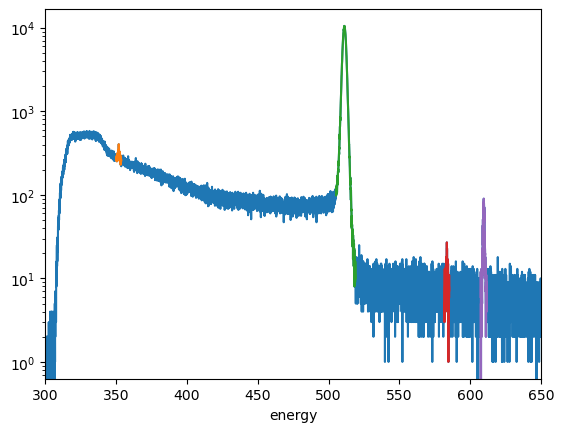

In [18]:
spectrum.data.plot(yscale='log')
for domain in peaks_domains:
    domain.plot()
plt.xlim([300,650])